In [1]:
!pip install librosa scipy matplotlib numpy --quiet

# Лабораторная 9 

# ___________________________________________________________________________________

### Подключение библиотек

In [2]:
import os
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from aeon.datasets import load_from_ts_file
from aeon.testing.data_generation import make_example_1d_numpy
from aeon.distances import euclidean_distance
from aeon.transformations.collection.shapelet_based import RandomShapeletTransform 
from aeon.classification.shapelet_based import ShapeletTransformClassifier          
from sklearn.linear_model import RidgeClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = [11, 7]
plt.rcParams["figure.dpi"] = 100
np.random.seed(42)

In [3]:
from aeon.testing.data_generation import make_example_3d_numpy

X_dummy, _ = make_example_3d_numpy(n_cases=5, n_channels=1, n_timepoints=50, random_state=42)
_ = euclidean_distance(X_dummy[0], X_dummy[1])
print("Проверка расстояний: OK")

Проверка расстояний: OK


Предварительная проверка numba-функций (на случай долгой компиляции)

### Загрузка данных

In [4]:
CAR_DIR = r"Z:\Work\ED\2trim\regressionlab\practic\Zee\CarDataset"

X_train, y_train = load_from_ts_file(os.path.join(CAR_DIR, "Car_TRAIN.ts"))
X_test,  y_test  = load_from_ts_file(os.path.join(CAR_DIR, "Car_TEST.ts"))

print(f"Обучение: {X_train.shape}, Тест: {X_test.shape}")
print(f"Классы: {np.unique(y_train)}")
print(f"Длина ряда: {X_train.shape[2]}")

Обучение: (60, 1, 577), Тест: (60, 1, 577)
Классы: ['1' '2' '3' '4']
Длина ряда: 577


Датасет Car: 60 обучающих и 60 тестовых примеров, 577 точек в каждом ряду, 4 класса. Данные одноканальные (1 канал).

### Исследовательский анализ

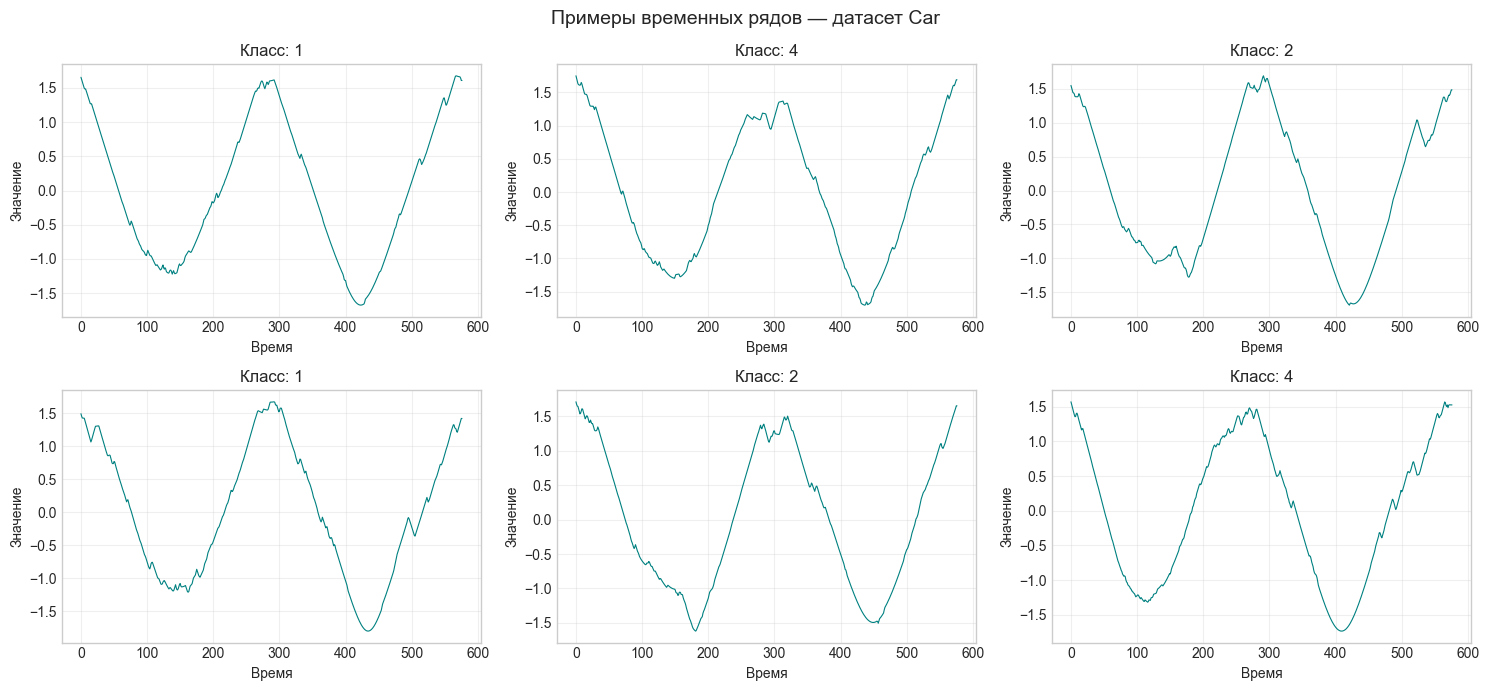

In [5]:
n_show = 6
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flatten()

for i in range(n_show):
    axes[i].plot(X_train[i, 0, :], color="teal", linewidth=0.8)
    axes[i].set_title(f"Класс: {y_train[i]}", fontsize=12)
    axes[i].set_xlabel("Время", fontsize=10)
    axes[i].set_ylabel("Значение", fontsize=10)
    axes[i].grid(True, alpha=0.3)

plt.suptitle("Примеры временных рядов — датасет Car", fontsize=14)
plt.tight_layout()
plt.show()

Визуально ряды различаются по форме и амплитуде. Некоторые классы имеют выраженные паттерны, другие более плавные

#### Shapelet-трансформация

In [6]:
# max_shapelet_length должен быть int, не float
# 0.1 от длины ряда Car = 577 точек -> 57
series_len = X_train.shape[2]
max_shp_len = max(3, int(0.1 * series_len))

rst = RandomShapeletTransform(
    n_shapelet_samples=500,
    max_shapelet_length=max_shp_len,
    random_state=42
)

X_train_t = rst.fit_transform(X_train, y_train)
X_test_t  = rst.transform(X_test)

print(f"Исходная размерность: {X_train.shape}")
print(f"max_shapelet_length: {max_shp_len}")
print(f"После Shapelet: {X_train_t.shape}")

Исходная размерность: (60, 1, 577)
max_shapelet_length: 57
После Shapelet: (60, 345)


Из 60 обучающих примеров извлечено 345 shapelet-признаков. Максимальная длина shapelet — 57 (10% от длины ряда 577). Размерность данных сокращена с (60, 1, 577) до (60, 345).

### Классификатор

In [7]:
# series_len уже вычислен в ячейке shapelet-code
stc = ShapeletTransformClassifier(
    n_shapelet_samples=500,
    max_shapelet_length=max_shp_len,
    random_state=42
)

stc.fit(X_train, y_train)
y_pred = stc.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Точность ShapeletTransformClassifier: {acc:.4f} ({acc*100:.2f}%)")

Точность ShapeletTransformClassifier: 0.7167 (71.67%)


ShapeletTransformClassifier показал точность 71.67% на 4-классовой задаче. Это существенно выше случайного уровня (25% для 4 классов).

#### Сравнение с RDST

In [8]:
from aeon.classification.shapelet_based import RDSTClassifier

# RDSTClassifier: параметр max_shapelets, не n_shapelets
rdst = RDSTClassifier(max_shapelets=500, random_state=42)
rdst.fit(X_train, y_train)
y_pred_rdst = rdst.predict(X_test)
acc_rdst = accuracy_score(y_test, y_pred_rdst)

print(f"Точность RDST: {acc_rdst:.4f} ({acc_rdst*100:.2f}%)")
print(f"Точность STC:  {acc:.4f} ({acc*100:.2f}%)")
print(f"Разница: {abs(acc - acc_rdst)*100:.2f}%")

Точность RDST: 0.9167 (91.67%)
Точность STC:  0.7167 (71.67%)
Разница: 20.00%


RDST показал 91.67%, что на 20% выше STC (71.67%). RDST использует случайные shapelet-признаки с дискретизацией и работает значительно быстрее, при этом существенно точнее на данном датасете.